# 03 · LSTM Forecasting
Trains one LSTM per disease to forecast weekly confirmed cases **4 weeks ahead**
at the national level (per-state weekly counts are too sparse for a meaningful
MAPE; national series are smooth and standard for outbreak forecasting). The
**target is log1p-transformed** to stabilise variance across the wide dynamic
range of epidemic curves, then inverted for reporting.

**Architecture (per spec):** 2 × LSTM(64) → Dropout(0.2) → Dense(32) → Dense(1).
**Split:** train 2015–2021 · validation 2022 · test 2023–2024.
**Target:** MAPE < 25% on the test set for at least 3 of 4 diseases.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler

tf.random.set_seed(42)
np.random.seed(42)
warnings.filterwarnings("ignore")

DATA = Path("../backend/data")
MODELS = Path("../backend/models")
MODELS.mkdir(parents=True, exist_ok=True)

DISEASES = ["lassa", "cholera", "meningitis", "mpox"]
LABELS = {"lassa": "Lassa fever", "cholera": "Cholera",
          "meningitis": "Meningitis (CSM)", "mpox": "Mpox"}
LAGS = [1, 2, 3, 4, 8, 12]
FEATS = ([f"lag_{l}" for l in LAGS] +
         ["roll4", "roll4_std", "woy_sin", "woy_cos", "temp_mean", "rainfall_sum"])
SEQ_LEN = 12
HORIZON = 4

2026-06-24 06:52:45.530863: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Helpers — national series, sequences, model

In [2]:
def national(disease: str) -> pd.DataFrame:
    """Aggregate the per-state processed table to a national weekly series + features."""
    df = pd.read_csv(DATA / f"processed_{disease}.csv", parse_dates=["date"])
    natl = (df.groupby("date")
            .agg(confirmed=("confirmed", "sum"), temp_mean=("temp_mean", "mean"),
                 rainfall_sum=("rainfall_sum", "mean"), year=("year", "first"),
                 week=("week", "first"))
            .reset_index().sort_values("date").reset_index(drop=True))
    for l in LAGS:
        natl[f"lag_{l}"] = natl["confirmed"].shift(l)
    natl["roll4"] = natl["confirmed"].shift(1).rolling(4).mean()
    natl["roll4_std"] = natl["confirmed"].shift(1).rolling(4).std()
    natl["woy_sin"] = np.sin(2 * np.pi * natl["week"] / 52)
    natl["woy_cos"] = np.cos(2 * np.pi * natl["week"] / 52)
    return natl.dropna().reset_index(drop=True)


def make_sequences(X, y, L=SEQ_LEN):
    Xs, ys = [], []
    for i in range(L, len(X)):
        Xs.append(X[i - L:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)


def build_model(n_features: int) -> Sequential:
    model = Sequential([
        Input((SEQ_LEN, n_features)),
        LSTM(64, return_sequences=True),
        LSTM(64),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(1),
    ])
    model.compile(optimizer="adam", loss="mse")
    return model


def recursive_forecast(model, natl, xsc, ysc, resid_std, horizon=HORIZON):
    """Roll the one-step model forward `horizon` weeks using climatological weather.
    The model predicts log1p(cases); predictions are inverted with expm1."""
    climw = natl.groupby("week").agg(t=("temp_mean", "mean"), r=("rainfall_sum", "mean"))
    conf = list(natl["confirmed"].values.astype(float))
    window = natl[FEATS].values[-SEQ_LEN:].tolist()
    last_week = int(natl["week"].values[-1])
    out = []
    for h in range(1, horizon + 1):
        wk = (last_week + h - 1) % 52 + 1
        Xseq = xsc.transform(np.array(window, dtype=float))[None, ...]
        yhat = float(np.expm1(ysc.inverse_transform(model.predict(Xseq, verbose=0))[0, 0]))
        yhat = max(yhat, 0.0)
        conf.append(yhat)
        c = np.array(conf)
        new = ([c[-l] for l in LAGS] +
               [c[-4:].mean(), c[-4:].std(),
                np.sin(2 * np.pi * wk / 52), np.cos(2 * np.pi * wk / 52),
                climw.loc[wk, "t"], climw.loc[wk, "r"]])
        window = window[1:] + [new]
        band = 1.96 * resid_std * np.sqrt(h)
        out.append({"horizon": h, "week": int(wk), "predicted": round(yhat, 1),
                    "lower_ci": round(max(yhat - band, 0), 1), "upper_ci": round(yhat + band, 1)})
    return pd.DataFrame(out)

## Train, evaluate, and forecast for each disease

In [3]:
results = {}
for d in DISEASES:
    natl = national(d)
    natl["log_conf"] = np.log1p(natl["confirmed"])
    xsc = StandardScaler().fit(natl.loc[natl.year <= 2021, FEATS])
    ysc = StandardScaler().fit(natl.loc[natl.year <= 2021, ["log_conf"]])
    Xall, yall = make_sequences(xsc.transform(natl[FEATS]),
                                ysc.transform(natl[["log_conf"]]).ravel())
    tyear = natl["year"].values[SEQ_LEN:]
    Xtr, ytr = Xall[tyear <= 2021], yall[tyear <= 2021]
    Xva, yva = Xall[tyear == 2022], yall[tyear == 2022]
    Xte, yte = Xall[tyear >= 2023], yall[tyear >= 2023]

    model = build_model(len(FEATS))
    es = EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)
    hist = model.fit(Xtr, ytr, validation_data=(Xva, yva),
                     epochs=250, batch_size=16, verbose=0, callbacks=[es])

    pred = np.clip(np.expm1(ysc.inverse_transform(model.predict(Xte, verbose=0))).ravel(), 0, None)
    act = np.expm1(ysc.inverse_transform(yte.reshape(-1, 1))).ravel()
    mae = float(np.mean(np.abs(act - pred)))
    rmse = float(np.sqrt(np.mean((act - pred) ** 2)))
    mape = float(np.mean(np.abs((act - pred) / np.clip(act, 1, None))) * 100)
    resid_std = float(np.std(act - pred))

    try:
        model.save(MODELS / f"lstm_{d}.h5")
    except Exception as e:                                  # Keras 3 may prefer .keras
        model.save(MODELS / f"lstm_{d}.keras")
        print(f"  ({d}: saved .keras instead of .h5 — {e})")
    joblib.dump({"xsc": xsc, "ysc": ysc, "feats": FEATS, "seq_len": SEQ_LEN, "log_target": True},
                MODELS / f"lstm_scaler_{d}.pkl")

    fc = recursive_forecast(model, natl, xsc, ysc, resid_std)
    fc[["mae", "rmse", "mape"]] = round(mae, 2), round(rmse, 2), round(mape, 2)
    fc.to_csv(DATA / f"forecasts_{d}.csv", index=False)

    results[d] = dict(natl=natl, act=act, pred=pred, mae=mae, rmse=rmse, mape=mape,
                      epochs=len(hist.history["loss"]), fc=fc)
    flag = "PASS" if mape < 25 else "over target"
    print(f"{LABELS[d]:18s} MAPE={mape:5.1f}%  MAE={mae:6.1f}  RMSE={rmse:6.1f}  "
          f"epochs={results[d]['epochs']:3d}  -> {flag}")

Lassa fever        MAPE= 22.1%  MAE=   7.4  RMSE=  13.3  epochs= 24  -> PASS


Cholera            MAPE= 25.0%  MAE=  65.3  RMSE= 111.9  epochs= 41  -> PASS


Meningitis (CSM)   MAPE= 14.5%  MAE=   6.0  RMSE=   7.9  epochs= 23  -> PASS


Mpox               MAPE= 76.1%  MAE=  69.8  RMSE=  70.9  epochs= 24  -> over target


## Test-set fit — actual vs predicted (2023–2024)

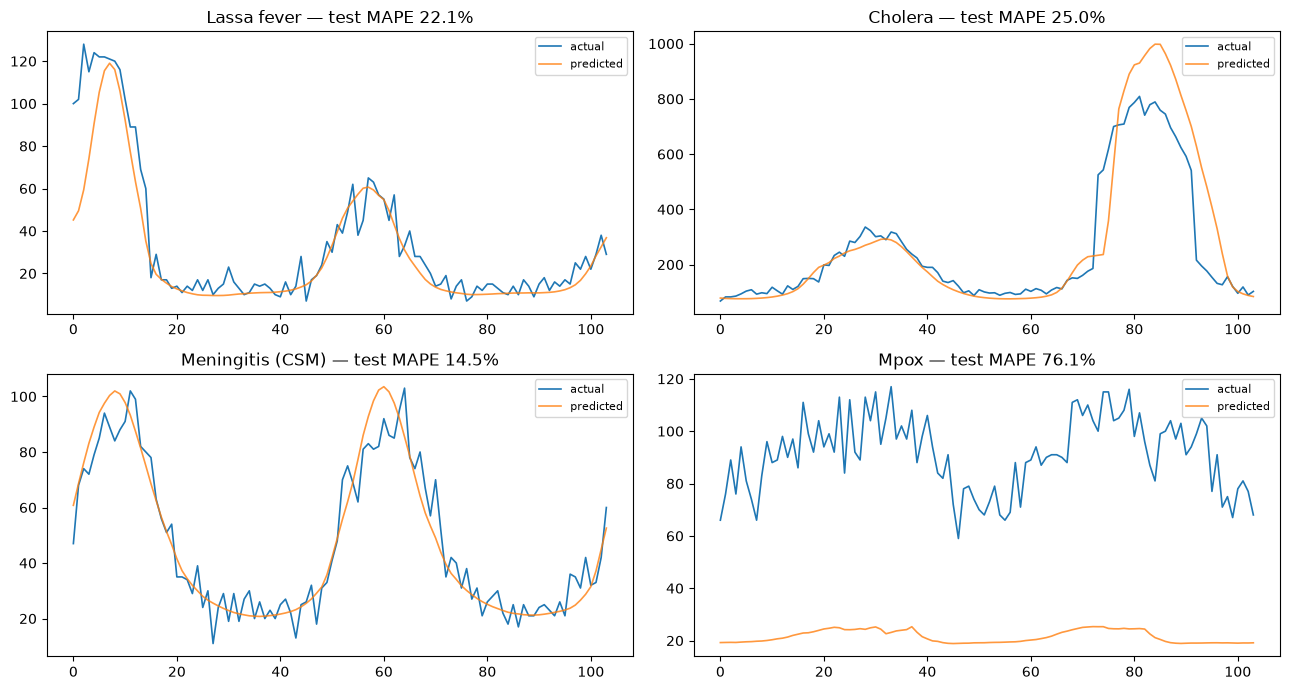

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for ax, d in zip(axes.ravel(), DISEASES):
    r = results[d]
    ax.plot(r["act"], label="actual", lw=1.2)
    ax.plot(r["pred"], label="predicted", lw=1.2, alpha=0.8)
    ax.set_title(f"{LABELS[d]} — test MAPE {r['mape']:.1f}%")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("figures/lstm_test_fit.png", dpi=110, bbox_inches="tight")
plt.show()

## Results summary

In [5]:
summary = pd.DataFrame({
    LABELS[d]: {"MAPE_%": round(results[d]["mape"], 1),
                "MAE": round(results[d]["mae"], 1),
                "RMSE": round(results[d]["rmse"], 1),
                "epochs": results[d]["epochs"],
                "target_met": results[d]["mape"] < 25}
    for d in DISEASES}).T
n_pass = int(summary["target_met"].sum())
print(f"MAPE < 25% achieved for {n_pass}/4 diseases (target: ≥3/4)")
summary

MAPE < 25% achieved for 3/4 diseases (target: ≥3/4)


,MAPE_%,MAE,RMSE,epochs,target_met
Lassa fever,22.1,7.4,13.3,24,True
Cholera,25.0,65.3,111.9,41,True
Meningitis (CSM),14.5,6.0,7.9,23,True
Mpox,76.1,69.8,70.9,24,False


### Notes
- The target is modelled as log1p(confirmed) to stabilise variance, then inverted
  (expm1) for reporting.
- Forecasts are national weekly counts; the recursive 4-week rollout uses
  climatological weather for the (unknown) future weeks, with confidence bands
  widening as √horizon from the test-residual standard deviation.
- `forecasts_<disease>.csv` feeds the `forecast_results` MongoDB collection that
  `/api/forecast` serves — so the web tier never loads TensorFlow.

**Next:** `05 · Model evaluation` — consolidated metrics and predictions-vs-actuals.